# Week3 Assignment: Sequence Prediction with LSTM Networks
## Encoder-Decoder LSTMs for Learning Mathematical Operations

---

### Assignment Overview

In this assignment, you will build two LSTM-based models from scratch:

1. **Part A — Addition as a Mapping Problem:** Train a simple LSTM to directly map pairs of numbers to their sum (the "beginner's approach").
2. **Part B — Addition as a Seq2Seq Problem:** Frame addition as a true *sequence-to-sequence* prediction task, treating the arithmetic expression `"12+50"` as a character sequence and the result `"62"` as the output sequence. This is the correct, powerful use of LSTMs.
3. **Part C — Extensions & Analysis:** Extend the model and reflect critically on the differences.

### Learning Objectives

By completing this assignment, you will:
- Understand the difference between a **mapping problem** and a **sequence prediction problem**
- Implement a **stacked LSTM** for regression
- Implement an **Encoder-Decoder (Seq2Seq) LSTM** architecture with `RepeatVector` and `TimeDistributed` layers
- Understand **one-hot encoding** for character-level sequence modelling
- Evaluate and compare model performance using RMSE and accuracy

### Submission Instructions

- Run **all cells** before submitting (Kernel → Restart & Run All)
- Answer all written questions in the provided Markdown cells
- Do **not** delete any `# TODO` comments — fill them in
- Submit as `.ipynb`

---

---
## Section 0: Environment Setup

Run the cell below to install and import all required libraries. This assignment uses **TensorFlow/Keras**, NumPy, and scikit-learn.

> 💡 If you are on Google Colab, TensorFlow is pre-installed. On a local machine, run `pip install tensorflow scikit-learn` if needed.

In [94]:
# ── Imports ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from numpy import array, argmax
from random import seed, randint
from math import ceil, log10, sqrt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, TimeDistributed, RepeatVector

# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("All imports successful")

TensorFlow version : 2.21.0
NumPy version      : 2.4.3
All imports successful


---
## Part A: Addition as a Mapping Problem

### Background

A common beginner mistake when learning LSTMs is to frame a problem that *looks* sequential as a plain **mapping (function approximation)** task. When adding two numbers `[a, b] → a+b`, the order of `a` and `b` does not matter — you could shuffle the inputs and still get the right answer. This is **not** a sequence problem.

In this part, you will:
1. Generate training data (pairs of random integers and their sum)
2. Normalize the data
3. Build a simple stacked LSTM for regression
4. Evaluate with RMSE

> **Key insight:** After completing Part A and B, reflect on *why* the MLP and simple LSTM work just as well (or better) than a seq2seq model on this framing.

### Task A1: Data Generation

**Direction:** Implement the `random_sum_pairs` function below. It should:
- Generate `n_examples` pairs of random integers, each in the range `[1, largest]`
- Compute the sum of each pair
- Return normalized `X` and `y` arrays (divide by `largest * n_numbers`)

The normalization maps all values into `[0, 1]`, which is required for the LSTM's activation functions.

In [95]:
def random_sum_pairs(n_examples, n_numbers, largest):
    """
    Generate random integer pairs and their normalized sum.

    Parameters
    ----------
    n_examples : int  – number of samples to generate
    n_numbers  : int  – how many integers to add per sample
    largest    : int  – maximum value of each integer (inclusive)

    Returns
    -------
    X : np.ndarray of shape (n_examples, n_numbers) – normalized inputs
    y : np.ndarray of shape (n_examples,)            – normalized sums
    """
    # TODO ────────────────────────────────────────────────────────────────────
    # 1. Create empty lists X_list and y_list
    X_list=[]
    y_list=[]
    for i in range(n_examples):
        x=np.random.randint(1,largest+1,n_numbers)
        x=x.tolist()
        y=sum(x)
        X_list.append(x)
        y_list.append(y)
    X_list=np.array(X_list)
    y_list=np.array(y_list)
    X=X_list/(largest*n_numbers)
    y=y_list/(largest*n_numbers)
    return X, y
    # 2. Loop n_examples times:
    #      a. Generate a list of n_numbers random integers between 1 and largest
    #      b. Compute the sum of those integers
    #      c. Append the list to X_list and the sum to y_list
    # 3. Convert X_list and y_list to numpy arrays
    # 4. Normalize: divide X by (largest * n_numbers), y by (largest * n_numbers)
    # 5. Return X, y
    # ─────────────────────────────────────────────────────────────────────────
    #raise NotImplementedError("Implement random_sum_pairs()!")


def invert_sum(value, n_numbers, largest):
    """Convert a normalized prediction back to the original integer scale."""
    # TODO: multiply value by (largest * n_numbers) and round to nearest int
    value=value*(largest*n_numbers)
    value=np.round(value).flatten()
    return value
    #raise NotImplementedError("Implement invert_sum()!")


# ── Quick sanity check ───────────────────────────────────────────────────────
seed(1)
X_test, y_test = random_sum_pairs(5, 2, 10)
print("Sample X (normalized):", X_test[:3])
print("Sample y (normalized):", y_test[:3])
print("Reconstructed sums   :", [invert_sum(v, 2, 10) for v in y_test[:3]])

Sample X (normalized): [[0.35 0.2 ]
 [0.4  0.25]
 [0.35 0.5 ]]
Sample y (normalized): [0.55 0.65 0.85]
Reconstructed sums   : [array([11.]), array([13.]), array([17.])]


### Task A2: Build the LSTM Model

**Direction:** Build a stacked LSTM that accepts a sequence of `n_numbers` time steps (each with 1 feature) and outputs a single scalar (the predicted normalized sum).

Architecture to implement:
- `LSTM(10, input_shape=(n_numbers, 1))` — one hidden LSTM layer with 10 units
- `Dense(1)` — output layer (regression)
- Compile with **`mean_squared_error`** loss and **`adam`** optimizer

> The input must be reshaped to `(n_examples, n_numbers, 1)` — a 3D tensor of shape (samples, timesteps, features).

In [96]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
seed(1)
n_examples = 100
n_numbers  = 2
largest    = 100
n_batch    = 1
n_epoch    = 100

# ── TODO: Build the model ────────────────────────────────────────────────────

model_a = Sequential()  # replace with your implementation
model_a.add(LSTM(10,input_shape=(n_numbers,1)))
model_a.add(Dense(1))
model_a.compile(loss='mean_squared_error',optimizer='adam')

# TODO: print the model summary
model_a.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

### Task A3: Train the Model

**Direction:** Train `model_a` for `n_epoch` epochs. On each epoch:
1. Generate a fresh batch of `n_examples` samples using `random_sum_pairs`
2. Reshape `X` to `(n_examples, n_numbers, 1)` (add feature dimension)
3. Call `model_a.fit(X, y, epochs=1, batch_size=n_batch, verbose=0)`

Store the loss from each epoch in a list called `history_a` for plotting.

> Generating new data each epoch is a form of **online data augmentation** — the model never sees the exact same batch twice, which helps it generalize.

[0.11367630213499069, 0.024687420576810837, 0.016054151579737663, 0.011095723137259483, 0.01154376845806837, 0.006912521552294493, 0.005157293751835823, 0.004055642988532782, 0.00239730067551136, 0.0017405046382918954, 0.0011342510115355253, 0.0008159715798683465, 0.0007452538120560348, 0.0005769091658294201, 0.0005690248217433691, 0.00027053567464463413, 0.00027227692771703005, 0.00016334054816979915, 9.77089730440639e-05, 0.000114667353045661, 0.00011074929352616891, 8.974972297437489e-05, 7.087286212481558e-05, 8.813473687041551e-05, 6.476989801740274e-05, 7.523023668909445e-05, 6.894345278851688e-05, 6.506939826067537e-05, 7.933793676784262e-05, 5.285626684781164e-05, 6.42399609205313e-05, 5.516885357792489e-05, 5.7729794207261875e-05, 6.843364826636389e-05, 5.5644431995460764e-05, 4.692181391874328e-05, 7.006208033999428e-05, 5.735310696763918e-05, 3.0596565920859575e-05, 6.407307228073478e-05, 4.989859735360369e-05, 3.067242505494505e-05, 5.679014066117816e-05, 3.912780084647238e

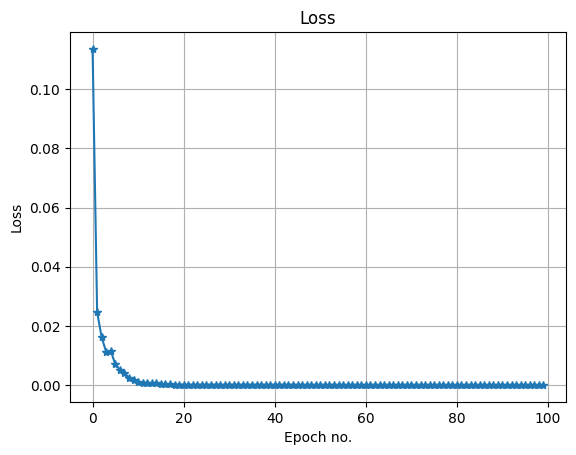

In [97]:
history_a = []

# TODO ────────────────────────────────────────────────────────────────────────
for i in range(n_epoch):
    X,y=random_sum_pairs(n_examples,n_numbers,largest)
    X=X.reshape(n_examples,n_numbers,1)
    hist=(model_a.fit(X,y,epochs=1,batch_size=n_batch,verbose=0))
    loss=hist.history['loss'][0]
    history_a.append(loss)
    

# ─────────────────────────────────────────────────────────────────────────────
print(history_a)
# ── Plot training loss ───────────────────────────────────────────────────────
# TODO: plot history_a with plt.plot — label axes and add a title
plt.plot(history_a,marker='*')
plt.xlabel('Epoch no.')
plt.ylabel('Loss')
plt.title('Loss')
plt.grid()
plt.show()

### Task A4: Evaluate the Model

**Direction:** Evaluate `model_a` on **100 new, unseen** samples:
1. Generate test data with `random_sum_pairs`
2. Reshape `X` to `(n_examples, n_numbers, 1)`
3. Predict with `model_a.predict`
4. Invert the normalization using `invert_sum`
5. Compute **RMSE** using `mean_squared_error` from sklearn
6. Print the first 20 predictions alongside the expected values and error

>  **Reflection Question (written answer below):** Is RMSE a good metric here? What metric would you consider "acceptable" for this problem?

In [98]:
# TODO ────────────────────────────────────────────────────────────────────────
X,y=random_sum_pairs(100,2,100)
X=X.reshape(100,2,1)
pred=model_a.predict(X,batch_size=n_batch,verbose=0)
input=X.reshape(100,2)
result=invert_sum(pred,2,100)
expected=invert_sum(y,2,100)
rmse=np.sqrt(mean_squared_error(expected,result))
print("RMSE:",rmse)
for i in range(20):
    error=expected[i]-result[i]
    print("Input:",input[i]*(100*2),"Prediciton:",result[i],"Expected:",expected[i],"Error:",error)

# ─────────────────────────────────────────────────────────────────────────────

RMSE: 0.7615773105863908
Input: [98. 43.] Prediciton: 140.0 Expected: 141.0 Error: 1.0
Input: [71. 17.] Prediciton: 88.0 Expected: 88.0 Error: 0.0
Input: [59.  3.] Prediciton: 62.0 Expected: 62.0 Error: 0.0
Input: [29. 22.] Prediciton: 51.0 Expected: 51.0 Error: 0.0
Input: [38. 54.] Prediciton: 91.0 Expected: 92.0 Error: 1.0
Input: [93. 50.] Prediciton: 142.0 Expected: 143.0 Error: 1.0
Input: [69. 30.] Prediciton: 98.0 Expected: 99.0 Error: 1.0
Input: [23. 85.] Prediciton: 108.0 Expected: 108.0 Error: 0.0
Input: [90. 47.] Prediciton: 136.0 Expected: 137.0 Error: 1.0
Input: [21. 20.] Prediciton: 41.0 Expected: 41.0 Error: 0.0
Input: [23. 68.] Prediciton: 90.0 Expected: 91.0 Error: 1.0
Input: [21. 21.] Prediciton: 42.0 Expected: 42.0 Error: 0.0
Input: [ 1. 15.] Prediciton: 16.0 Expected: 16.0 Error: 0.0
Input: [17. 51.] Prediciton: 67.0 Expected: 68.0 Error: 1.0
Input: [63. 14.] Prediciton: 77.0 Expected: 77.0 Error: 0.0
Input: [59. 83.] Prediciton: 142.0 Expected: 142.0 Error: 0.0
Input

#### Written Answer – Part A

**Q1.** What RMSE did you achieve? Is the model learning the task correctly?

*Your answer here:*

---

**Q2.** Could a simple MLP (fully connected network) solve this same problem? Why or why not?

*Your answer here:*

---

---
## Part B: Addition as a True Seq2Seq Problem

### Background

The "correct" and more powerful LSTM use-case treats the entire arithmetic expression as a **character-level sequence**. Given the input string `"12+50"` (character by character), the model must output the string `"62"` (character by character).

This is a **sequence-to-sequence (seq2seq)** problem:
- Input sequence: `['1', '2', '+', '5', '0']` → 5 timesteps, each one-hot encoded
- Output sequence: `['6', '2']` → 2 timesteps, each one-hot encoded

The architecture uses an **Encoder–Decoder** pattern with a `RepeatVector` bridge:

```
Input Chars  →  [Encoder LSTM]  →  Context Vector  →  [RepeatVector]
             →  [Decoder LSTM]  →  [TimeDistributed Dense]  →  Output Chars
```

In this part you will implement the full data pipeline and the model.

### Task B1: Convert Numbers to Padded Strings

**Direction:** Implement `to_string(X, y, n_numbers, largest)` that:
- Joins each input list like `[3, 10]` into the string `"3+10"`, padded on the left with spaces to fixed length
- Converts each sum integer to a right-padded string of fixed length
- Input max length formula: `n_numbers * ceil(log10(largest+1)) + n_numbers - 1`
- Output max length formula: `ceil(log10(n_numbers * (largest+1)))`

> **Why padding?** LSTMs require fixed-length input sequences. Padding with spaces allows variable-length numbers to be handled uniformly. The model learns to ignore the padding character.

In [99]:
def to_string(X, y, n_numbers, largest):
    """
    Convert integer lists and sum values to fixed-length padded strings.

    Parameters
    ----------
    X         : list of lists – e.g. [[3, 10], [5, 7]]
    y         : list of ints  – e.g. [13, 12]
    n_numbers : int
    largest   : int

    Returns
    -------
    X_str : list of str – e.g. [' 3+10', ' 5+ 7']
    y_str : list of str – e.g. ['13', '12']
    """
    # TODO ────────────────────────────────────────────────────────────────────
    # Compute max input length:
    X_str=[]
    y_str=[]
    max_in = n_numbers * ceil(log10(largest + 1)) + n_numbers - 1
    for pattern in X:
        strp = '+'.join([str(n) for n in pattern])
        strp= ' '*(max_in-len(strp)) + strp
        X_str.append(strp)
    #   left-pad strp with spaces to reach max_in length
    # Compute max output length:
    max_out = ceil(log10(n_numbers * (largest+1 )))
    print("MAx:",max_out)
    for value in y:
        strp = str(value)
        strp= ' '*(max_out-len(strp)) + strp
        y_str.append(strp)
    #   left-pad strp with spaces to reach max_out length
    # ─────────────────────────────────────────────────────────────────────────
    return X_str,y_str
    #raise NotImplementedError("Implement to_string()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
seed(1)
X_raw, y_raw = random_sum_pairs(3, 2, 10)
# NOTE: random_sum_pairs returns normalized arrays — for seq2seq we need raw ints
# We'll re-generate without normalization using a helper below
def raw_sum_pairs(n_examples, n_numbers, largest):
    X_list, y_list = [], []
    for _ in range(n_examples):
        inp = [randint(1, largest) for _ in range(n_numbers)]
        X_list.append(inp); y_list.append(sum(inp))
    return X_list, y_list

X_raw, y_raw = raw_sum_pairs(3, 2, 10)
X_str, y_str = to_string(X_raw, y_raw, 2, 10)
print("Raw inputs :", X_raw)
print("Str inputs :", X_str)
print("Str outputs:", y_str)

MAx: 2
Raw inputs : [[3, 10], [2, 5], [2, 8]]
Str inputs : [' 3+10', '  2+5', '  2+8']
Str outputs: ['13', ' 7', '10']


### Task B2: Integer Encode the Character Strings

**Direction:** Implement `integer_encode(X, y, alphabet)` that maps each character in every string to its index in `alphabet`.

The alphabet for this problem is:
```python
alphabet = ['0','1','2','3','4','5','6','7','8','9','+', ' ']
```
So `'0'` → `0`, `'+'` → `10`, `' '` (space) → `11`.

> This is a necessary stepping stone before one-hot encoding. It converts strings into sequences of integers that can be further encoded.

In [100]:
ALPHABET = ['0','1','2','3','4','5','6','7','8','9','+', ' ']

def integer_encode(X, y, alphabet):
    """
    Map each character in each string to its index in alphabet.

    Returns
    -------
    X_enc : list of list of int
    y_enc : list of list of int
    """
    # TODO ────────────────────────────────────────────────────────────────────
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    X_enc=[]
    y_enc=[]
    # For each string pattern in X, convert each character to its integer index
    for i in range(len(y)):
        s=[]
        for ch in X[i]:
            s.append(char_to_int[ch])
        X_enc.append(s)
        s=[]
        for ch in y[i]:
            s.append(char_to_int[ch])
        y_enc.append(s)
        
    # Do the same for y

    # ─────────────────────────────────────────────────────────────────────────
    return X_enc,y_enc
    #raise NotImplementedError("Implement integer_encode()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
X_int, y_int = integer_encode(X_str, y_str, ALPHABET)
print("Integer-encoded X:", X_int)
print("Integer-encoded y:", y_int)

Integer-encoded X: [[11, 3, 10, 1, 0], [11, 11, 2, 10, 5], [11, 11, 2, 10, 8]]
Integer-encoded y: [[1, 3], [11, 7], [1, 0]]


### Task B3: One-Hot Encode the Integer Sequences

**Direction:** Implement `one_hot_encode(X, y, n_classes)` that converts each integer index into a binary vector of length `n_classes` with a `1` at the index position and `0` elsewhere.

For example, index `3` with `n_classes=12` becomes:
```
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
```

> One-hot encoding frames each character position as a **multi-class classification** output. The model will use a softmax output layer and categorical cross-entropy loss.

In [101]:
def one_hot_encode(X, y, n_classes):
    """
    Convert integer-encoded sequences to one-hot binary vectors.

    Returns
    -------
    X_enc : list of list of list (shape: [n_samples, seq_len, n_classes])
    y_enc : list of list of list (shape: [n_samples, out_len, n_classes])
    """
    # TODO ────────────────────────────────────────────────────────────────────
    X_enc=[]
    y_enc=[]
    # For each sample in X (a list of integer indices):
    for sample_x in X:
      list_list_x=[]
      for ch in sample_x:
            temp=[0]*n_classes
            temp[ch]=1
            list_list_x.append(temp)
      X_enc.append(list_list_x)
    for sample_y in y:
      list_list_y=[]
      for ch in sample_y:
            temp=[0]*n_classes
            temp[ch]=1
            list_list_y.append(temp)
      y_enc.append(list_list_y)

    #   For each index, create a zero vector of length n_classes
    #   Set vector[index] = 1
    # Do the same for y
    # ─────────────────────────────────────────────────────────────────────────
    return X_enc,y_enc
    raise NotImplementedError("Implement one_hot_encode()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
X_ohe, y_ohe = one_hot_encode(X_int, y_int, len(ALPHABET))
print("Shape of X_ohe[0]:", array(X_ohe[0]).shape,
      "(should be (input_seq_len, 12))")
print("Shape of y_ohe[0]:", array(y_ohe[0]).shape,
      "(should be (output_seq_len, 12))")

Shape of X_ohe[0]: (5, 12) (should be (input_seq_len, 12))
Shape of y_ohe[0]: (2, 12) (should be (output_seq_len, 12))


### Task B4: Assemble the Full Data Pipeline

**Direction:** Implement `generate_data(n_samples, n_numbers, largest, alphabet)` that chains all steps:
1. `raw_sum_pairs` → integer lists
2. `to_string` → padded strings
3. `integer_encode` → integer sequences
4. `one_hot_encode` → binary tensors
5. Return as numpy arrays

In [102]:
def generate_data(n_samples, n_numbers, largest, alphabet):
    """Full pipeline: integers → one-hot encoded numpy arrays."""
    # TODO ────────────────────────────────────────────────────────────────────
    # Call each function in order, then convert to numpy arrays
    # ─────────────────────────────────────────────────────────────────────────
    X_raw,y_raw=raw_sum_pairs(n_samples,n_numbers,largest)
    X_str, y_str = to_string(X_raw, y_raw, n_numbers, largest)
    X_enc, y_enc= integer_encode(X_str,y_str,alphabet)
    X_enc, y_enc= one_hot_encode(X_enc,y_enc,12)
    X_enc=np.array(X_enc)
    y_enc=np.array(y_enc)
    return X_enc,y_enc
    #raise NotImplementedError("Implement generate_data()!")


def invert_ohe(seq, alphabet):
    """Decode a one-hot output sequence back to a string."""
    int_to_char = {i: c for i, c in enumerate(alphabet)}
    return ''.join(int_to_char[argmax(v)] for v in seq)


# ── Compute sequence length constants ────────────────────────────────────────
seed(1)
n_samples_b  = 1000
n_numbers_b  = 2
largest_b    = 10
n_chars      = len(ALPHABET)
n_in_len     = n_numbers_b * ceil(log10(largest_b + 1)) + n_numbers_b - 1
n_out_len    = ceil(log10(n_numbers_b * (largest_b +1)))

print(f"Input  sequence length : {n_in_len}")
print(f"Output sequence length : {n_out_len}")
print(f"Alphabet size          : {n_chars}")

# ── Test generate_data ────────────────────────────────────────────────────────
X_b, y_b = generate_data(4, n_numbers_b, largest_b, ALPHABET)
print(f"\nX shape: {X_b.shape}  (should be (4, {n_in_len}, {n_chars}))")
print(f"y shape: {y_b.shape}  (should be (4, {n_out_len}, {n_chars}))")

Input  sequence length : 5
Output sequence length : 2
Alphabet size          : 12
MAx: 2

X shape: (4, 5, 12)  (should be (4, 5, 12))
y shape: (4, 2, 12)  (should be (4, 2, 12))


### Task B5: Build the Encoder-Decoder LSTM Model

**Direction:** Build the seq2seq LSTM model with the following architecture:

```
Input: (n_in_len, n_chars)
  └─ Encoder LSTM (100 units)  → Context vector (100,)
       └─ RepeatVector(n_out_len) → (n_out_len, 100)
            └─ Decoder LSTM (50 units, return_sequences=True)
                 └─ TimeDistributed(Dense(n_chars, activation='softmax'))
Output: (n_out_len, n_chars)
```

- **Encoder:** A single LSTM that reads the input sequence and compresses it to a fixed-size context vector
- **RepeatVector:** Repeats the context vector `n_out_len` times so the decoder can produce a sequence
- **Decoder:** An LSTM + Dense that generates one output character at a time
- **Loss:** `categorical_crossentropy` | **Optimizer:** `adam` | **Metric:** `accuracy`

> **Why RepeatVector?** The encoder outputs a 2D tensor `(batch, 100)`. The decoder LSTM needs a 3D input `(batch, timesteps, features)`. `RepeatVector(n)` repeats the vector `n` times, bridging the gap.

In [103]:
# ── Define hyperparameters ────────────────────────────────────────────────────
n_batch_b  = 10
n_epoch_b  = 30

# TODO: Build the Encoder-Decoder LSTM ────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
model_b=Sequential()
model_b.add(LSTM(100,input_shape=(n_in_len,n_chars)))
model_b.add(RepeatVector(n_out_len))
model_b.add(LSTM(50,return_sequences=True))
model_b.add(TimeDistributed(Dense(n_chars,activation='softmax')))
model_b.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model_b.summary())



Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100)            │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 2, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 2, 50)          │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 2, 12)          │           612 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,012 (296.92 KB)

 Trainable params: 76,012 (296.92 KB)

 Non-trainable params: 0 (0.00 B)

None


### Task B6: Train the Seq2Seq Model

**Direction:** Train `model_b` for `n_epoch_b` epochs. Each epoch:
1. Generate `n_samples_b` fresh examples with `generate_data`
2. Fit for 1 epoch with `batch_size=n_batch_b`
3. Record both `loss` and `accuracy` for plotting

MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3615 - loss: 1.9709
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3595 - loss: 1.5370
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3850 - loss: 1.4646
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4655 - loss: 1.3557
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5310 - loss: 1.2689
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6000 - loss: 1.1448
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6190 - loss: 1.0175
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6965 - loss: 0.8852
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7755 - loss: 0.7648
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7870 - loss: 0.7054
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8510 - loss: 0.5957
MAx: 2
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8615 - loss: 0.5443
MAx: 2
100/100 ━

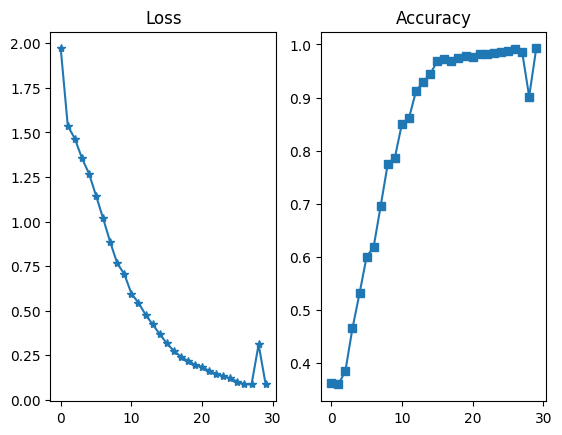

In [104]:
history_b_loss = []
history_b_acc  = []
for i in range(n_epoch_b):
    X,y=generate_data(n_samples_b,n_numbers_b,largest_b,ALPHABET)
    hist=model_b.fit(X,y,epochs=1,batch_size=n_batch_b)
    loss=hist.history['loss'][0]
    accuracy=hist.history['accuracy'][0]
    history_b_loss.append(loss)
    history_b_acc.append(accuracy)
# TODO ────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────

# ── Plot ──────────────────────────────────────────────────────────────────────
# TODO: Plot both loss and accuracy curves on side-by-side subplots
plt.subplot(1,2,1)
plt.plot(history_b_loss,marker='*')
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history_b_acc,marker='s')
plt.title('Accuracy')
plt.show()

### Task B7: Evaluate the Seq2Seq Model

**Direction:** Generate 100 test samples and evaluate the model:
1. Predict with `model_b.predict`
2. Decode predictions using `invert_ohe`
3. Print the first 20 (expected, predicted) pairs
4. Compute **character-level accuracy**: the percentage of predictions that exactly match the expected string

> An "exact match" means the model predicted *every character correctly* — a stricter metric than element-wise accuracy.

In [105]:
# TODO ────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
X,y=generate_data(100,2,100,ALPHABET)
pred=model_b.predict(X,batch_size=10,verbose=0)
print(X.shape , y.shape,pred.shape)
result = [invert_ohe(pred[i], ALPHABET) for i in range(len(pred))]
y_decoded = [invert_ohe(y[i], ALPHABET) for i in range(len(y))]
X_decoded = [invert_ohe(X[i], ALPHABET) for i in range(len(X))]
print("Input:",X_decoded)
print("Expected:",y_decoded)
print("Prediction:",result)
print("Input:     ", X_decoded[0])
print("Expected:  ", y_decoded[0])
print("Prediction:", result[0])

MAx: 3
(100, 7, 12) (100, 3, 12) (100, 2, 12)
Input: ['  95+38', '  80+28', '  95+37', '   2+36', '  92+78', '   9+56', '  98+47', '  29+95', '   6+99', '  52+95', '  30+84', '  97+74', '  76+31', '  65+86', '  76+21', '   1+77', '   22+6', '  57+47', '  85+42', '  22+21', '  50+26', '  41+64', '  27+63', '  53+21', '  16+55', '  21+16', '  85+83', '  10+50', '  29+41', '  50+31', '  64+78', '  76+43', '  70+98', '   52+6', '  78+29', '  36+78', '  40+13', '  10+88', '  96+76', '  66+20', '  34+19', '  18+87', '  15+61', ' 99+100', '  97+32', '  11+32', '  53+18', '  46+28', '   9+55', '  45+25', '   63+5', '  40+50', '  57+44', '  26+31', '  59+35', '  18+87', '   55+4', '   8+54', '  54+23', '  63+64', '  13+60', '  49+48', '  65+12', '  11+78', '   10+8', '  30+73', '   70+7', '  85+74', '  52+64', '  45+65', '  87+86', '  16+27', '   2+70', '  96+55', '  61+46', '  63+21', '  98+70', '  81+27', '  73+20', '  45+40', '  65+29', '  81+83', '  56+74', '  14+41', '   4+43', '  74+33', 

#### Written Answer – Part B

**Q3.** What exact-match accuracy did your seq2seq model achieve? Does increasing `n_epoch_b` improve results?

*Your answer here:*

---

**Q4.** Explain the role of `RepeatVector` in the encoder-decoder architecture. What would happen if you removed it and directly connected the encoder output to the decoder?

*Your answer here:*

---

**Q5.** Why is `TimeDistributed(Dense(...))` used instead of a plain `Dense` layer for the output?

*Your answer here:*

---

---
## Part C : Extensions & Critical Analysis

This section challenges you to go beyond the baseline and critically compare the two approaches.

> These tasks are designed to deepen your understanding. Partial credit is given for thoughtful reasoning even if results are not perfect.

### Task C1: MLP Baseline Comparison

**Direction:** Build a simple **Multi-Layer Perceptron (MLP)** to solve the same mapping problem as Part A. Compare its RMSE to the LSTM's RMSE.

Architecture:
- `Dense(4, input_dim=n_numbers, activation='relu')`
- `Dense(2, activation='relu')`
- `Dense(1)`

Train for 50 epochs, batch_size=2, same data generation as Part A.

In [106]:
# TODO ────────────────────────────────────────────────────────────────────────
# Build, train, and evaluate the MLP.
# Print RMSE and compare to Part A.
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────

#### Written Answer – Task C1

**Q6.** Which model (MLP vs LSTM) achieved lower RMSE for the mapping problem? What does this reveal about when LSTMs are the right tool?

*Your answer here:*

---

### Task C2: Scale to Larger Numbers

**Direction:** Retrain your seq2seq model (`model_b`) but change the dataset configuration to **3 numbers in the range 1–99** (i.e., `n_numbers=3, largest=99`). You will need to:
1. Recompute `n_in_len` and `n_out_len`
2. Rebuild and retrain `model_b` with the new input/output shapes
3. Report the final accuracy

> You may need to increase `n_epoch_b` to 50 or more. Note how the model complexity needs to scale with the input difficulty.

In [107]:
# TODO ────────────────────────────────────────────────────────────────────────
# n_numbers_c = 3
# largest_c   = 99
# Recompute n_in_len_c, n_out_len_c
# Rebuild and retrain the seq2seq model
# Evaluate and report accuracy
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────

#### Written Answer – Task C2

**Q7.** How did accuracy change when you scaled from 2 numbers (1–10) to 3 numbers (1–99)? What architectural or training changes helped?

*Your answer here:*

---

### Task C3: Loss Curve Analysis & Visualization

**Direction:** Plot a combined figure with:
1. Part A LSTM loss curve
2. Part B seq2seq loss and accuracy curves

Then write a brief analysis below comparing the convergence behaviour.

In [108]:
# TODO ────────────────────────────────────────────────────────────────────────
# Create a figure with 3 subplots side by side:
#   1. Part A loss (history_a)
#   2. Part B loss (history_b_loss)
#   3. Part B accuracy (history_b_acc)
# Label all axes. Add a title to each subplot.
# ─────────────────────────────────────────────────────────────────────────────



#### Written Answer – Task C3

**Q8.** Describe the shape of the loss curves. Did either model show signs of overfitting? Which converged faster?

*Your answer here:*

---

### Task C4: Error Analysis – Where Does the Seq2Seq Model Fail?

**Direction:** Generate 500 test samples and identify:
1. Which predicted strings were **incorrect** (expected ≠ predicted)
2. Whether errors tend to occur on certain **types of inputs** (e.g., sums with carry digits, larger numbers, etc.)
3. Print 10 representative failure cases

> This is an open-ended analysis task. There's no single correct answer — the goal is to reason carefully about model limitations.

In [109]:
# TODO ────────────────────────────────────────────────────────────────────────
# Generate 500 test samples
# Identify all incorrect predictions
# Analyze patterns in failures
# Print 10 failure cases with their inputs (re-generate the raw inputs alongside)
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────

#### Written Answer – Task C4

**Q9.** What patterns did you observe in the failure cases? Is the model making systematic errors (e.g., always off by 1 in a specific digit position)?

*Your answer here:*

---

---
## Part D (Bonus): Subtraction Seq2Seq

**Direction (Bonus — Optional):** Extend your seq2seq model to learn **subtraction** instead of (or in addition to) addition.

Changes required:
1. Modify `raw_sum_pairs` to generate `a - b` pairs (ensure `a >= b` to avoid negatives, or handle negative sign in the alphabet)
2. Update the alphabet to include `'-'` if needed
3. Re-train and evaluate

> For extra challenge: support **mixed operations** — randomly assign `+`,`*`,`/` or `-` per sample, and let the model figure out which operation to apply based on the string input.

In [110]:
# BONUS TODO ──────────────────────────────────────────────────────────────────
# Implement subtraction (or mixed operations) seq2seq below.
# ─────────────────────────────────────────────────────────────────────────────

# Hint for subtraction:
def raw_subtract_pairs(n_examples, largest):
    X_list, y_list = [], []
    for _ in range(n_examples):
        a, b = sorted([randint(1, largest), randint(1, largest)], reverse=True)
        X_list.append([a, b])
        y_list.append(a - b)
    return X_list, y_list

print("Bonus task — implement subtraction seq2seq here!")

Bonus task — implement subtraction seq2seq here!


#### Written Answer – Part D

**Q10 (Bonus).** Did the model successfully learn subtraction? What was the hardest part of extending the approach?

*Your answer here (optional):*

---

---
## Final Summary

Fill in the table below after completing all parts:

| Task | Model | Metric | Your Result |
|------|-------|--------|-------------|
| Part A | Stacked LSTM | RMSE | |
| Part C1 | MLP Baseline | RMSE | |
| Part B | Seq2Seq LSTM | Exact-match Accuracy (%) | |
| Part C2 | Seq2Seq (scaled) | Exact-match Accuracy (%) | |
| Part D (Bonus) | Subtraction Seq2Seq | Exact-match Accuracy (%) | |

---

### Key Takeaways

Reflect briefly on the three most important things you learned from this assignment:

1. *Your answer here*
2. *Your answer here*
3. *Your answer here*

---

*Assignment based on: [MachineLearningMastery.com — Learn to Add Numbers with an Encoder-Decoder LSTM](https://machinelearningmastery.com/learn-add-numbers-seq2seq-recurrent-neural-networks/)*